In [1]:
EIA_API_KEY = "qJAKLoC3ZZuOZ0TnkcYpNTmQoD6uasIdYtpeKnw2"

import os, requests, pandas as pd
os.makedirs('data', exist_ok=True)

records, offset = [], 0
while True:
    r = requests.get(
        "https://api.eia.gov/v2/electricity/rto/region-data/data/",
        params={
            "api_key": EIA_API_KEY, "frequency": "hourly", "data[0]": "value",
            "facets[respondent][]": "CAR", "facets[type][]": "NG",
            "start": "2026-02-01T00", "end": "2026-04-30T23",
            "sort[0][column]": "period", "sort[0][direction]": "asc",
            "length": 5000, "offset": offset,
        },
        timeout=30,
    )
    r.raise_for_status()
    payload = r.json()
    records.extend(payload["response"]["data"])
    offset += len(payload["response"]["data"])
    if offset >= int(payload["response"]["total"]):
        break

eia_df = pd.DataFrame(records)[["period", "value"]]
eia_df.columns = ["timestamp", "ng_mwh"]
eia_df["ng_mwh"] = pd.to_numeric(eia_df["ng_mwh"], errors="coerce")
eia_df.to_csv("data/EIA930_CAR_NG_2026_3mo.csv", index=False)

asos_path = "data/KCLT_asos_2026_3mo.csv"
if not os.path.exists(asos_path):
    r = requests.get("https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py", params={
        "station": "KCLT", "data": ["tmpf", "dwpf", "relh", "sknt"],
        "year1": 2026, "month1": 2, "day1": 1,
        "year2": 2026, "month2": 5, "day2": 1,
        "tz": "UTC", "format": "onlycomma", "latlon": "no", "direct": "no", "report_type": 3,
    }, timeout=60)
    with open(asos_path, "w") as f:
        f.write(r.text)

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

DATA_DIR = 'data'
FIG_DIR  = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Load EIA-930 Balance Data

In [3]:
def load_eia_data(data_dir):
    csv_files = sorted(glob.glob(os.path.join(data_dir, 'EIA930*.csv')))
    if not csv_files:
        raise FileNotFoundError(f"No EIA CSV files found in '{data_dir}'.")

    frames = []
    for fpath in csv_files:
        df = pd.read_csv(fpath, low_memory=False)
        df.columns = df.columns.str.strip()

        if 'ng_mwh' in df.columns and 'timestamp' in df.columns:
            frames.append(df[['timestamp', 'ng_mwh']].copy())
            continue

        ts_col = next(
            (c for c in df.columns if 'utc' in c.lower() and 'time' in c.lower()),
            next((c for c in df.columns if 'time' in c.lower()), None)
        )
        region_col = next(
            (c for c in df.columns if c.lower() in ('respondent', 'balancing_authority', 'ba', 'region')),
            next((c for c in df.columns if 'respond' in c.lower() or 'region' in c.lower()), None)
        )
        ng_col = next(
            (c for c in df.columns if 'natural gas' in c.lower()),
            next((c for c in df.columns if c.strip().upper() == 'NG'), None)
        )
        if ts_col is None or ng_col is None:
            raise ValueError(f"Cannot parse {os.path.basename(fpath)}: {list(df.columns)}")
        if region_col:
            df = df[df[region_col].astype(str).str.upper().str.contains('CAR')]
        df = df[[ts_col, ng_col]].copy()
        df.columns = ['timestamp', 'ng_mwh']
        df['ng_mwh'] = pd.to_numeric(df['ng_mwh'], errors='coerce')
        frames.append(df)

    eia = pd.concat(frames, ignore_index=True)
    eia['timestamp'] = pd.to_datetime(eia['timestamp'], utc=True, errors='coerce')
    eia = eia.dropna(subset=['timestamp'])
    eia = eia.sort_values('timestamp').drop_duplicates('timestamp').set_index('timestamp')
    print(f"EIA: {len(eia):,} rows | {eia.index.min().date()} → {eia.index.max().date()}")
    return eia

eia = load_eia_data(DATA_DIR)

EIA: 2,136 rows | 2026-02-01 → 2026-04-30


## 2. Load ASOS Weather Data (KCLT — Charlotte Douglas)

In [4]:
def load_asos_data(data_dir):
    candidates = sorted(
        glob.glob(os.path.join(data_dir, '*KCLT*.csv')) +
        glob.glob(os.path.join(data_dir, '*kclt*.csv')) +
        glob.glob(os.path.join(data_dir, '*asos*.csv')) +
        glob.glob(os.path.join(data_dir, '*weather*.csv'))
    )
    if not candidates:
        raise FileNotFoundError(f"No ASOS weather CSV found in '{data_dir}'.")

    df = pd.read_csv(candidates[0], low_memory=False, na_values=['M', 'T', ' ', ''])
    df.columns = df.columns.str.strip().str.lower()

    ts_col = next((c for c in df.columns if c in ('valid', 'datetime', 'time', 'date_time')), df.columns[0])
    col_map = {}
    for c in df.columns:
        if c in ('tmpf', 'temp', 'temperature', 'air_temp'):         col_map[c] = 'temp_f'
        elif c in ('dwpf', 'dew_point', 'dewpoint', 'dew_point_f'):  col_map[c] = 'dewp_f'
        elif c in ('relh', 'rhum', 'humidity', 'relative_humidity'): col_map[c] = 'humidity'
        elif c in ('sknt', 'wind_speed', 'wspd', 'windspeed'):        col_map[c] = 'wind_kts'

    df = df.rename(columns=col_map)
    keep = [ts_col] + [v for v in ('temp_f', 'dewp_f', 'humidity', 'wind_kts') if v in df.columns]
    df = df[keep].copy()
    df['timestamp'] = pd.to_datetime(df[ts_col], utc=True, errors='coerce')
    df = df.drop(columns=[ts_col]).dropna(subset=['timestamp'])
    for c in ('temp_f', 'dewp_f', 'humidity', 'wind_kts'):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.set_index('timestamp').resample('h').mean()
    print(f"ASOS: {len(df):,} hourly rows | {df.index.min().date()} → {df.index.max().date()}")
    return df

weather = load_asos_data(DATA_DIR)

ASOS: 2,160 hourly rows | 2026-02-01 → 2026-05-01


## 3. Merge & Handle Missing Values

In [5]:
merged = eia.resample('h').mean().join(weather, how='inner').ffill().bfill()

print(f"Merged: {len(merged):,} rows | {merged.index.min().date()} → {merged.index.max().date()}")
print(f"Missing values:\n{merged.isna().sum()}")
merged.head()

Merged: 2,136 rows | 2026-02-01 → 2026-04-30
Missing values:
ng_mwh      0
temp_f      0
dewp_f      0
humidity    0
wind_kts    0
dtype: int64


,ng_mwh,temp_f,dewp_f,humidity,wind_kts
timestamp,,,,,
2026-02-01 00:00:00+00:00,41554.0,21.0,17.0,84.25,12.0
2026-02-01 01:00:00+00:00,41182.0,20.0,15.0,80.59,11.0
2026-02-01 02:00:00+00:00,41279.0,19.0,14.0,80.51,15.0
2026-02-01 03:00:00+00:00,40616.0,18.0,14.0,84.04,11.0
2026-02-01 04:00:00+00:00,40160.0,17.0,12.0,80.34,11.0


## 4. Feature Engineering

In [6]:
def add_features(df):
    df = df.copy()
    df['hour']        = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month']       = df.index.month
    df['season']      = df['month'].map(
        {12:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3}
    )
    df['ng_lag24'] = df['ng_mwh'].shift(24)  # same hour, previous day
    df = df.dropna()

    weather_cols = [c for c in ('temp_f', 'humidity') if c in df.columns]
    feature_cols = ['hour', 'day_of_week', 'month', 'season'] + weather_cols + ['ng_lag24']
    return df[feature_cols], df['ng_mwh']

X, y = add_features(merged)
print(f"Features: {list(X.columns)}")
print(f"Rows: {len(X):,} | Target mean: {y.mean():.0f} MWh | std: {y.std():.0f}")
X.describe().round(2)

Features: ['hour', 'day_of_week', 'month', 'season', 'temp_f', 'humidity', 'ng_lag24']
Rows: 2,112 | Target mean: 23774 MWh | std: 4372


,hour,day_of_week,month,season,temp_f,humidity,ng_lag24
count,2112.00,2112.00,2112.00,2112.00,2112.00,2112.00,2112.00
mean,11.50,2.93,3.03,0.69,58.34,55.80,23942.69
std,6.92,1.99,0.80,0.46,14.60,21.28,4633.59
min,0.00,0.00,2.00,0.00,11.00,12.71,14883.00
25%,5.75,1.00,2.00,0.00,48.00,37.44,20900.00
50%,11.50,3.00,3.00,1.00,60.00,54.36,23067.50
75%,17.25,5.00,4.00,1.00,68.00,72.95,26258.75
max,23.00,6.00,4.00,1.00,89.00,96.57,41554.00


## 5. Train / Test Split (80/20, temporal order preserved)

In [7]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:  {len(X_test):,} rows  ({X_test.index.min().date()} → {X_test.index.max().date()})")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 1,689 rows (2026-02-02 → 2026-04-13)
Test:  423 rows  (2026-04-13 → 2026-04-30)


## 6. Model 1 — Ridge Regression

In [8]:
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0], cv=5)
ridge_cv.fit(X_train_sc, y_train)

y_pred_ridge = ridge_cv.predict(X_test_sc)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_r  = mean_absolute_error(y_test, y_pred_ridge)
r2_r   = r2_score(y_test, y_pred_ridge)

print(f"Alpha: {ridge_cv.alpha_} | RMSE: {rmse_r:,.1f} | MAE: {mae_r:,.1f} | R²: {r2_r:.4f}")

Alpha: 100.0 | RMSE: 2,622.7 | MAE: 2,106.6 | R²: 0.5011


## 7. Model 2 — MLP Neural Network (sklearn)

In [9]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_sc, y_train)

y_pred_mlp = mlp.predict(X_test_sc)
rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mae_m  = mean_absolute_error(y_test, y_pred_mlp)
r2_m   = r2_score(y_test, y_pred_mlp)

print(f"Iterations: {mlp.n_iter_} | RMSE: {rmse_m:,.1f} | MAE: {mae_m:,.1f} | R²: {r2_m:.4f}")

Iterations: 500 | RMSE: 1,750.7 | MAE: 1,403.9 | R²: 0.7777


## 8. Model Comparison Summary

In [10]:
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'MLP Neural Network'],
    'RMSE (MWh)': [rmse_r, rmse_m],
    'MAE (MWh)':  [mae_r,  mae_m],
    'R²':         [r2_r,   r2_m]
})
print(results.to_string(index=False))
winner = results.loc[results['RMSE (MWh)'].idxmin(), 'Model']
print(f"\nLower RMSE: {winner}")

             Model  RMSE (MWh)   MAE (MWh)       R²
  Ridge Regression 2622.721850 2106.627780 0.501147
MLP Neural Network 1750.741194 1403.913671 0.777714

Lower RMSE: MLP Neural Network


## 9. Visualizations

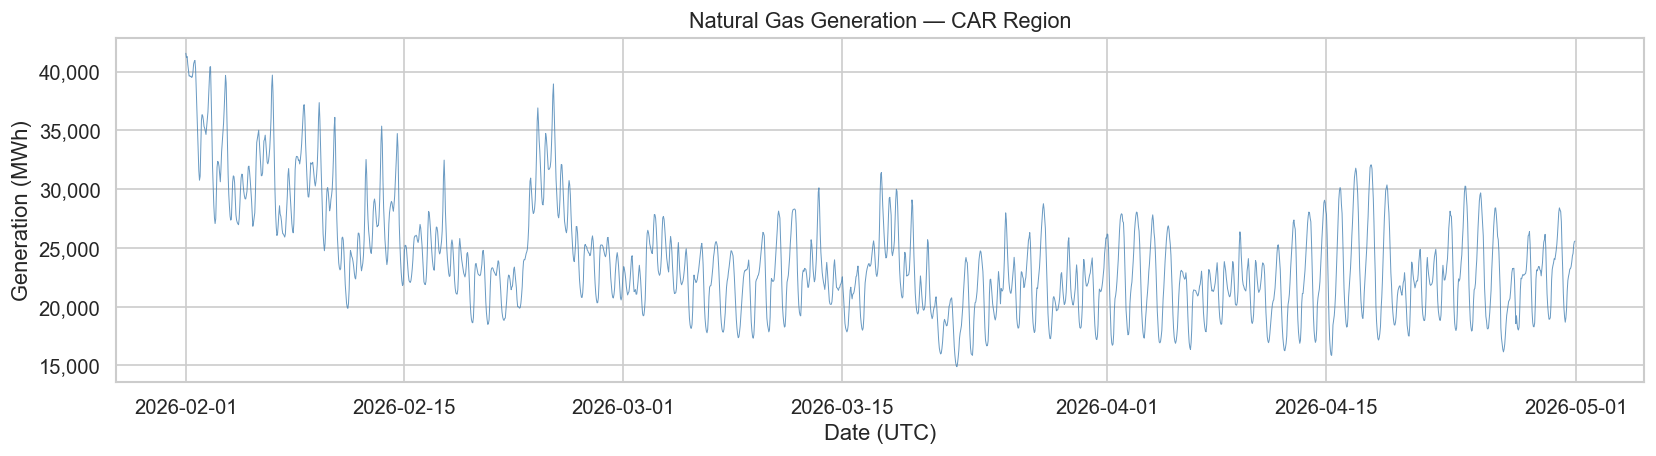

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(merged.index, merged['ng_mwh'], linewidth=0.6, color='steelblue', alpha=0.8)
ax.set_title('Natural Gas Generation — CAR Region', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Generation (MWh)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_timeseries.png'))
plt.show()

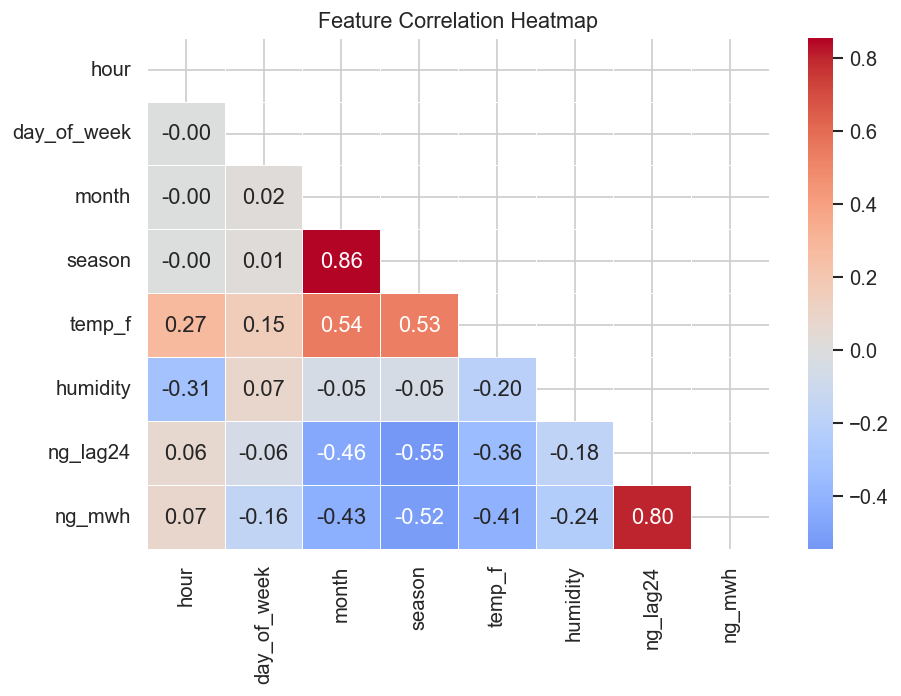

In [12]:
corr_df = X.copy()
corr_df['ng_mwh'] = y

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_correlation_heatmap.png'))
plt.show()

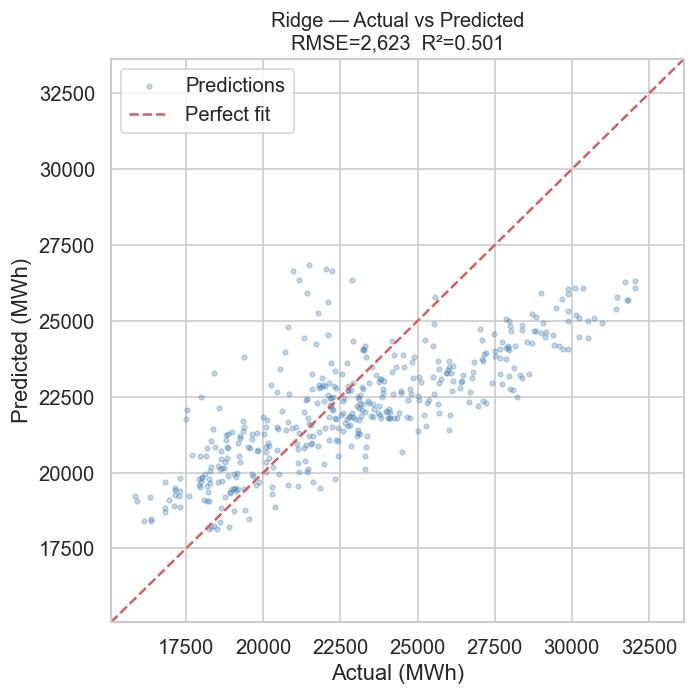

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
lim = [min(y_test.min(), y_pred_ridge.min()) * 0.95,
       max(y_test.max(), y_pred_ridge.max()) * 1.05]
ax.scatter(y_test, y_pred_ridge, alpha=0.3, s=8, color='steelblue', label='Predictions')
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual (MWh)'); ax.set_ylabel('Predicted (MWh)')
ax.set_title(f'Ridge — Actual vs Predicted\nRMSE={rmse_r:,.0f}  R²={r2_r:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_actual_vs_pred_ridge.png'))
plt.show()

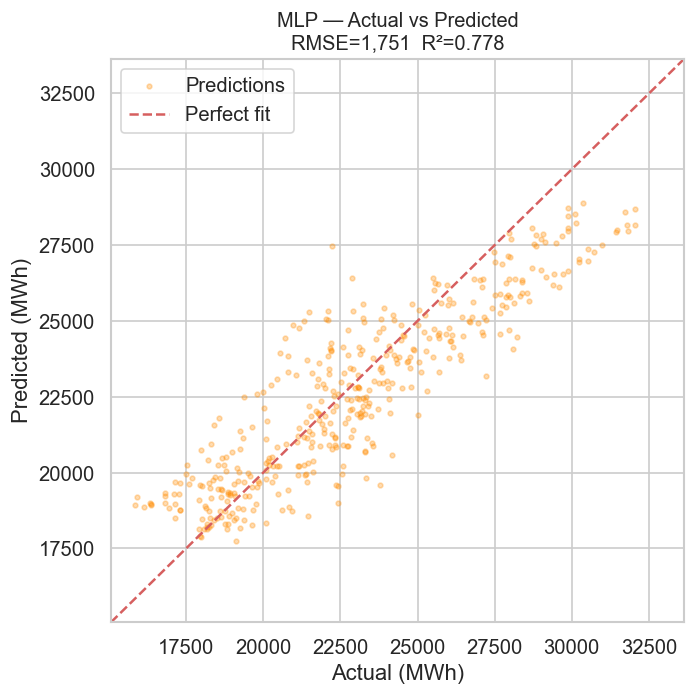

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
lim = [min(y_test.min(), y_pred_mlp.min()) * 0.95,
       max(y_test.max(), y_pred_mlp.max()) * 1.05]
ax.scatter(y_test, y_pred_mlp, alpha=0.3, s=8, color='darkorange', label='Predictions')
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual (MWh)'); ax.set_ylabel('Predicted (MWh)')
ax.set_title(f'MLP — Actual vs Predicted\nRMSE={rmse_m:,.0f}  R²={r2_m:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_actual_vs_pred_mlp.png'))
plt.show()

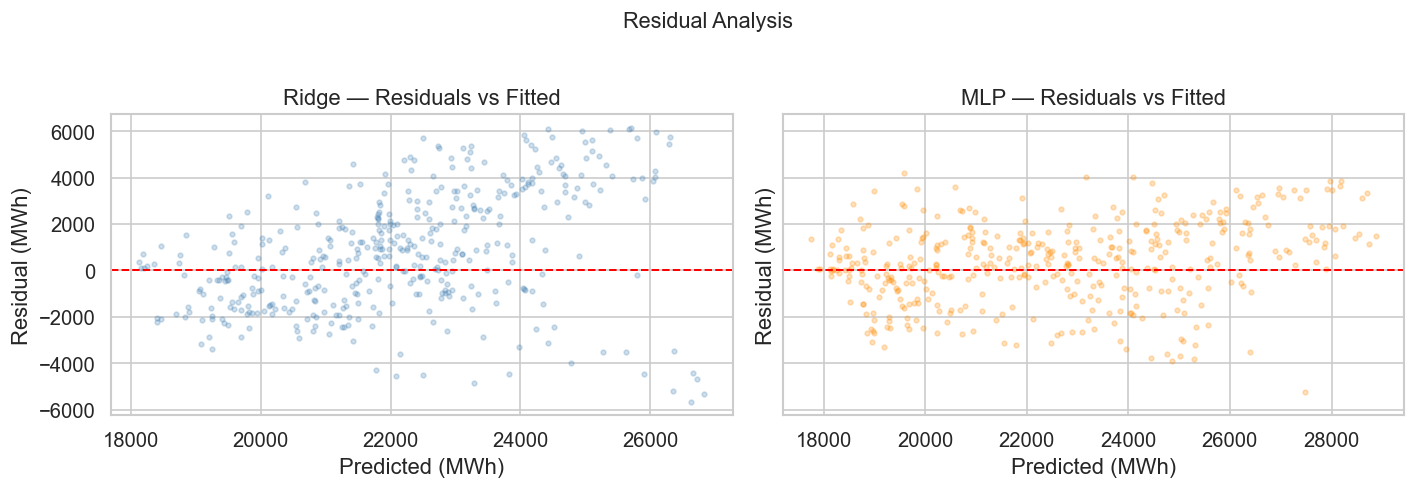

In [15]:
resid_ridge = y_test.values - y_pred_ridge
resid_mlp   = y_test.values - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, resid, pred, name, color in [
    (axes[0], resid_ridge, y_pred_ridge, 'Ridge',  'steelblue'),
    (axes[1], resid_mlp,   y_pred_mlp,   'MLP',    'darkorange')
]:
    ax.scatter(pred, resid, alpha=0.25, s=8, color=color)
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Predicted (MWh)')
    ax.set_ylabel('Residual (MWh)')
    ax.set_title(f'{name} — Residuals vs Fitted')

plt.suptitle('Residual Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_residuals.png'), bbox_inches='tight')
plt.show()

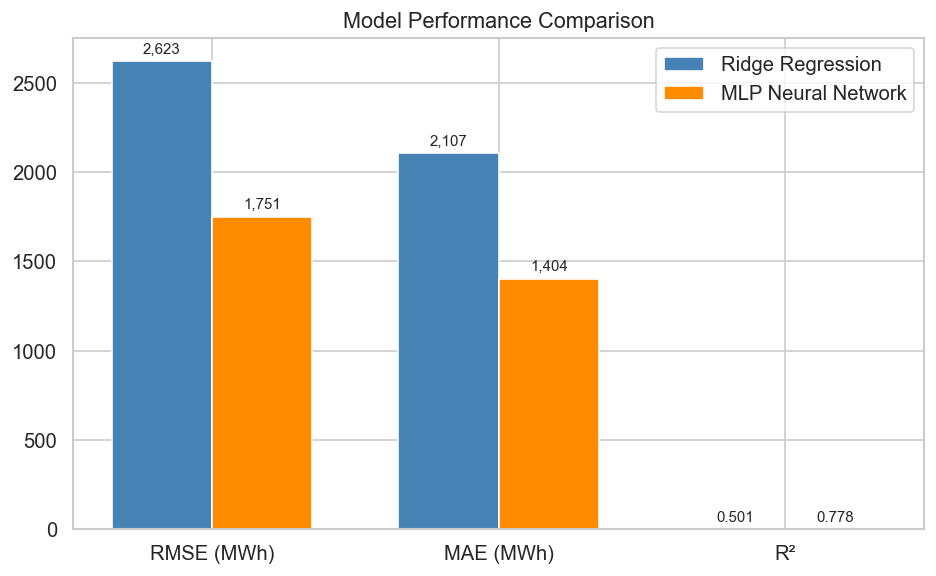

In [16]:
metrics    = ['RMSE (MWh)', 'MAE (MWh)', 'R²']
ridge_vals = [rmse_r, mae_r, r2_r]
mlp_vals   = [rmse_m, mae_m, r2_m]
x, width   = np.arange(len(metrics)), 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_r = ax.bar(x - width/2, ridge_vals, width, label='Ridge Regression', color='steelblue')
bars_m = ax.bar(x + width/2, mlp_vals,   width, label='MLP Neural Network', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend()

for bar in list(bars_r) + list(bars_m):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}' if h < 2 else f'{h:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_metrics_comparison.png'))
plt.show()

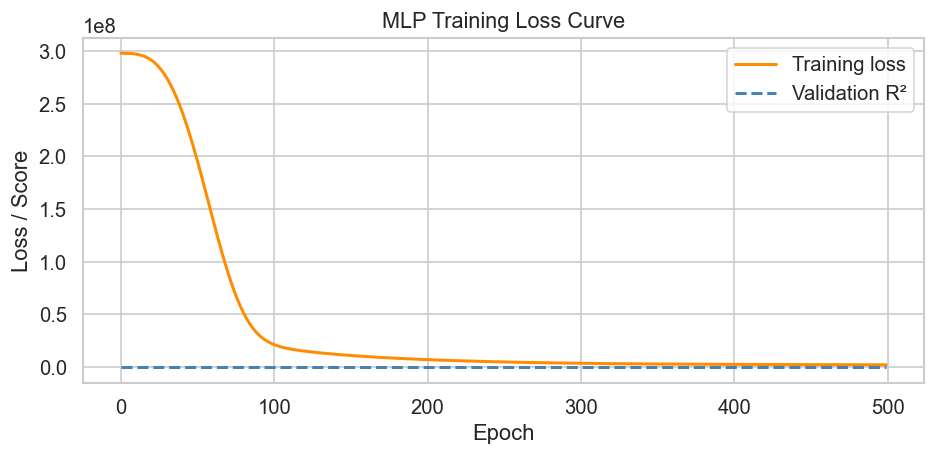

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, color='darkorange', linewidth=1.8, label='Training loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax.plot(mlp.validation_scores_, color='steelblue', linewidth=1.8, linestyle='--', label='Validation R²')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / Score')
ax.set_title('MLP Training Loss Curve', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_mlp_loss_curve.png'))
plt.show()

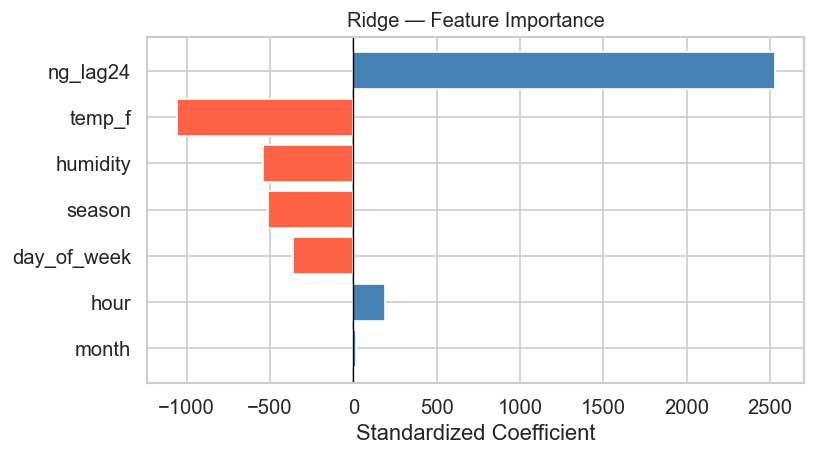

In [18]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_cv.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Ridge — Feature Importance', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_ridge_coefficients.png'))
plt.show()

## Done — All figures saved to `/figures`

In [19]:
saved = sorted(glob.glob(os.path.join(FIG_DIR, '*.png')))
print(f"{len(saved)} figures saved:")
for f in saved:
    print(f"  {f}")

print("\n=== Final Results ===")
print(results.to_string(index=False))

8 figures saved:
  figures/fig1_timeseries.png
  figures/fig2_correlation_heatmap.png
  figures/fig3_actual_vs_pred_ridge.png
  figures/fig4_actual_vs_pred_mlp.png
  figures/fig5_residuals.png
  figures/fig6_metrics_comparison.png
  figures/fig7_mlp_loss_curve.png
  figures/fig8_ridge_coefficients.png

=== Final Results ===
             Model  RMSE (MWh)   MAE (MWh)       R²
  Ridge Regression 2622.721850 2106.627780 0.501147
MLP Neural Network 1750.741194 1403.913671 0.777714
